# Actor-Critic on Wumpus World (4x4) — NumPy only

Trains **separate** Actor and Critic networks (imported from
`actor_network.py` and `critic_network.py`) on a randomly generated
4x4 Wumpus grid. No torch/sklearn — pure NumPy.

In [1]:
# ---------------------------------------------------------------------------
# Prompt for reproducing this notebook (train_actor_critic.ipynb):
#
# Implement an Actor-Critic (A2C) trainer over the NumPy-only modules
# `actor_network.ActorNetwork` and `critic_network.CriticNetwork`, and the
# custom environment `wumpus_env.WumpusWorldEnv` (4x4 Wumpus World). Do NOT
# use torch, sklearn, or any auto-diff/ML library — only numpy, math, random,
# and matplotlib (plots only). Everything must be hand-written NumPy.
#
# Training contract (exact):
#   1) Build actor= ActorNetwork(seed=0), critic= CriticNetwork(seed=0).
#   2) Use plain SGD with no momentum; lr_actor=1e-3, lr_critic=1e-3.
#      Maintain velocity states per (W,b) updated as:
#        v = v + lr*dW ;  W = clip(W - v, -weight_clip, weight_clip).
#      Gradients and weights are clipped (grad_clip=1.0, weight_clip=20.0)
#      to keep the bootstrapped value network from diverging.
#   3) Each episode: env= WumpusWorldEnv(max_steps=50); reset(). Loop until
#      done. Action selection: logits= actor.forward(s); probs=
#      softmax(logits); sample action via np.random.multinomial(1, probs);
#      keep log_prob= log(probs[action]).
#   4) One training step per env step (online A2C):
#        state s, next state s' , reward r, done d.
#        v  = critic.forward(s)
#        v' = critic.forward(s') if not done else 0.0
#        target = r/REWARD_SCALE + gamma*v' ;  REWARD_SCALE=100.0, gamma=0.99
#        advantage = clip(target - v, -ADV_CLIP, ADV_CLIP);  ADV_CLIP=10.0
#      Critic (value) update by gradient descent on MSE:
#        dV = advantage                       (scalar)
#        run backprop through the critic MLP.
#      Actor (policy) update by policy gradient with entropy bonus:
#        H = -sum(prob*log(prob))
#        dL/dlogits = -advantage*(probs - onehot) - ENTROPY_COEF*probs*(log(probs)+H)
#        dL/dlogits = clip(dL/dlogits, -5, 5)
#        run backprop through the actor MLP.
#   5) Hyperparameters: lr_actor=1e-3, lr_critic=1e-3, gamma=0.99,
#      reward_scale=100.0, adv_clip=10.0, grad_clip=1.0, max_steps=50,
#      episodes=2000, entropy_coef=0.02.
#   6) Record cumulative reward per episode. Print avg of last 200 every 200
#      episodes. Plot reward vs episode + moving avg (window=100).
#   7) After training, print a 4x4 deterministic policy grid: for each cell
#      (x,y) use actor.forward([breeze,stench,glitter,x*0.4,y*0.4]) argmax
#      action, names {0:Up,1:Down,2:Left,3:Right}.
#   8) Do a final sample run on a fresh map (seed=123): greedy argmax
#      actions, print each step reward/outcome and the total.
# ---------------------------------------------------------------------------

import random
import math
import numpy as np
import matplotlib.pyplot as plt

from actor_network import ActorNetwork
from critic_network import CriticNetwork
from wumpus_env import WumpusWorldEnv

random.seed(0)
np.random.seed(0)

## Backprop helpers + hyperparameters

In [2]:
def forward_with_cache(net, x):
    """Forward pass caching each layer's (input, pre-activation z, activation a).
    Returns (output, list of (a_in, z, a) per layer) for use in backprop."""
    x = np.asarray(x, dtype=np.float32)
    acts = []  # (a_in, z, a) for each layer; a_in is the layer's input
    a_in = x
    h = x
    for i, (W, b) in enumerate(net.layers):
        z = W @ h + b
        a = z if i == len(net.layers) - 1 else np.maximum(z, 0)
        acts.append((a_in, z, a))
        a_in = a
        h = a
    return h, acts


def backward(net, acts, grad_out):
    """Backprop through net. Returns gradients as list parallel to net.layers.
    grad_out is gradient w.r.t. network output (same shape as output)."""
    n_layers = len(net.layers)
    g = grad_out
    grads = []
    for i in range(n_layers - 1, -1, -1):
        a_in, z, a = acts[i]
        if i < n_layers - 1:
            g = g * (z > 0)  # ReLU derivative
        W, b = net.layers[i]
        dW = np.outer(g, a_in)
        db = g
        if i > 0:
            g = W.T @ g  # propagate gradient to the previous layer's output
        grads.append((dW, db))
    grads.reverse()
    return grads


def sgd_step(net, grads, lr, velocities, grad_clip=1.0, weight_clip=20.0):
    """Gradient-clipped SGD applied in place to net.layers.
    Returns updated velocities. dW/db clipped to +-grad_clip, and weights are
    hard-clipped to +-weight_clip to prevent value-network divergence."""
    for i, (dW, db) in enumerate(grads):
        W, b = net.layers[i]
        vW, vb = velocities[i]
        dW = np.clip(dW, -grad_clip, grad_clip)
        db = np.clip(db, -grad_clip, grad_clip)
        vW = vW + lr * dW
        vb = vb + lr * db
        W[:] = np.clip(W - vW, -weight_clip, weight_clip)
        b[:] = np.clip(b - vb, -weight_clip, weight_clip)
        net.layers[i] = (W, b)
        velocities[i] = (vW, vb)
    return velocities


LR_ACTOR = 1e-3
LR_CRITIC = 1e-3
GAMMA = 0.99
REWARD_SCALE = 100.0   # scale raw rewards in the TD target for stability
ADV_CLIP = 10.0        # clip advantage magnitude
GRAD_CLIP = 1.0        # clip per-parameter gradient magnitude
MAX_STEPS = 50
EPISODES = 2000
ENTROPY_COEF = 0.02

actor = ActorNetwork(seed=0)
critic = CriticNetwork(seed=0)
actor_vel = [(np.zeros_like(W), np.zeros_like(b)) for W, b in actor.layers]
critic_vel = [(np.zeros_like(W), np.zeros_like(b)) for W, b in critic.layers]

## Training loop

In [3]:
env = WumpusWorldEnv(max_steps=MAX_STEPS)
episode_rewards = []
ACTION_NAMES = {0: "Up", 1: "Down", 2: "Left", 3: "Right"}

for episode in range(EPISODES):
    state = np.asarray(env.reset(), dtype=np.float32)
    done = False
    total_reward = 0.0

    while not done:
        # Actor forward + sample
        logits, actor_acts = forward_with_cache(actor, state)
        e = np.exp(logits - np.max(logits))
        probs = e / e.sum()
        action = int(np.random.multinomial(1, probs).argmax())
        log_prob = math.log(probs[action])
        entropy = -float(np.sum(probs * np.log(probs + 1e-8)))

        next_state_np, reward, done, _truncated, _info = env.step(action)
        total_reward += reward
        next_state = np.asarray(next_state_np, dtype=np.float32)

        # Critic values (use reward scaled to keep the bootstrapped target bounded)
        value = critic.forward(state)
        next_value = 0.0 if done else critic.forward(next_state)
        target = reward / REWARD_SCALE + GAMMA * next_value
        advantage = float(np.clip(target - value, -ADV_CLIP, ADV_CLIP))

        # --- Critic update (MSE via manual backprop; gradient ~ advantage) ---
        _critic_out, critic_acts = forward_with_cache(critic, state)
        grad_v = np.array([advantage], dtype=np.float32)
        critic_grads = backward(critic, critic_acts, grad_v)
        critic_vel = sgd_step(critic, critic_grads, LR_CRITIC, critic_vel, GRAD_CLIP)

        # --- Actor update (policy gradient + entropy) ---
        # dL/dlogits = -advantage*(probs - onehot) - ENTROPY_COEF*p*(log p + H)
        onehot = np.zeros_like(probs)
        onehot[action] = 1.0
        d_logits = -(advantage) * (probs - onehot) - ENTROPY_COEF * probs * (np.log(probs + 1e-8) + entropy)
        d_logits = np.clip(d_logits, -5.0, 5.0).astype(np.float32)
        actor_grads = backward(actor, actor_acts, d_logits)
        actor_vel = sgd_step(actor, actor_grads, LR_ACTOR, actor_vel, GRAD_CLIP)

        state = next_state

    episode_rewards.append(total_reward)
    if (episode + 1) % 200 == 0:
        print(f"Episode {episode + 1}/{EPISODES}  avg_reward(last 200) = {np.mean(episode_rewards[-200:]):.2f}")

Episode 200/2000  avg_reward(last 200) = -57.18


Episode 400/2000  avg_reward(last 200) = -53.00


Episode 600/2000  avg_reward(last 200) = -57.25


Episode 800/2000  avg_reward(last 200) = -56.25


Episode 1000/2000  avg_reward(last 200) = -53.50


Episode 1200/2000  avg_reward(last 200) = -51.75


Episode 1400/2000  avg_reward(last 200) = -55.25


Episode 1600/2000  avg_reward(last 200) = -51.00


Episode 1800/2000  avg_reward(last 200) = -54.00


Episode 2000/2000  avg_reward(last 200) = -51.25


## Learning curve

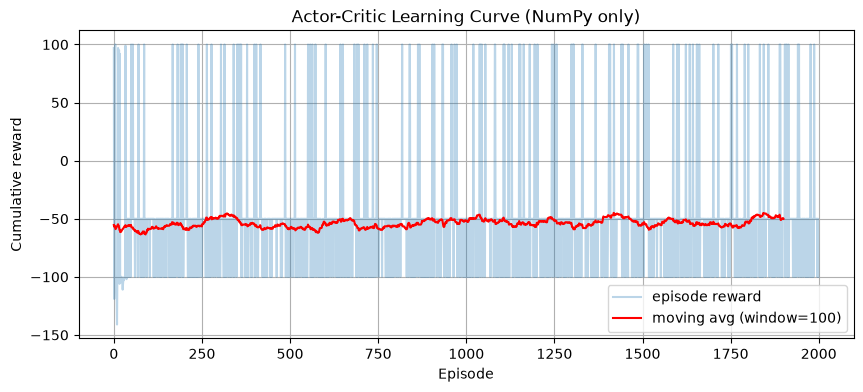

In [4]:
window = 100
if len(episode_rewards) >= window:
    moving_avg = np.convolve(episode_rewards, np.ones(window) / window, mode="valid")
else:
    moving_avg = episode_rewards

plt.figure(figsize=(10, 4))
plt.plot(episode_rewards, alpha=0.3, label="episode reward")
plt.plot(moving_avg, color="red", label=f"moving avg (window={window})")
plt.xlabel("Episode")
plt.ylabel("Cumulative reward")
plt.title("Actor-Critic Learning Curve (NumPy only)")
plt.legend()
plt.grid(True)
plt.show()

## Deterministic best-action policy grid

For each cell, greedy (argmax) action from the trained actor.

In [5]:
grid_size = env.size
policy = []
for y in range(grid_size):
    row = []
    for x in range(grid_size):
        st = np.asarray(
            [
                float(env._is_breeze((x, y))),
                float(env._is_stench((x, y))),
                float(env._is_glitter((x, y))),
                x * 0.4,
                y * 0.4,
            ],
            dtype=np.float32,
        )
        logits = actor.forward(st)
        row.append(ACTION_NAMES[int(np.argmax(logits))])
    policy.append(row)

print("Trained deterministic policy grid (y rows):")
for y in range(grid_size):
    print(policy[y])

Trained deterministic policy grid (y rows):
['Up', 'Up', 'Up', 'Up']
['Up', 'Up', 'Up', 'Up']
['Up', 'Up', 'Up', 'Up']
['Up', 'Up', 'Up', 'Up']


## Sample run on a fresh random map

In [6]:
env.reset(seed=123)
state = np.asarray(env.reset(), dtype=np.float32)
print(env)
env.render()

total = 0.0
done = False
steps = 0
while not done and steps < MAX_STEPS:
    logits = actor.forward(state)
    probs = np.exp(logits - np.max(logits))
    probs = probs / probs.sum()
    action = int(np.argmax(probs))
    state_np, reward, done, _t, info = env.step(action)
    state = np.asarray(state_np, dtype=np.float32)
    total += reward
    steps += 1
    print(f"step {steps}: action={ACTION_NAMES[action]:5s} reward={reward:4.0f} outcome={info['outcome']}")
    if done:
        break
print(f"Total reward: {total:.0f}")

WumpusWorldEnv(agent=(1, 1), breeze=1.0, stench=1.0, glitter=0.0, state=[1.0, 1.0, 0.0, 0.4000000059604645, 0.4000000059604645])
+---+---+---+---+
| . | P | . | . |
+---+---+---+---+
| . | A | G | . |
+---+---+---+---+
| . | W | P | . |
+---+---+---+---+
| . | P | . | . |
+---+---+---+---+
step 1: action=Up    reward=  -1 outcome=move
step 2: action=Up    reward=  -1 outcome=move
step 3: action=Up    reward=  -1 outcome=move
step 4: action=Up    reward=  -1 outcome=move
step 5: action=Up    reward=  -1 outcome=move
step 6: action=Up    reward=  -1 outcome=move
step 7: action=Up    reward=  -1 outcome=move
step 8: action=Up    reward=  -1 outcome=move
step 9: action=Up    reward=  -1 outcome=move
step 10: action=Up    reward=  -1 outcome=move
step 11: action=Up    reward=  -1 outcome=move
step 12: action=Up    reward=  -1 outcome=move
step 13: action=Up    reward=  -1 outcome=move
step 14: action=Up    reward=  -1 outcome=move
step 15: action=Up    reward=  -1 outcome=move
step 16: acti